In [1]:
!pip -q install -U "transformers>=4.48.0" datasets evaluate accelerate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 106.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 104.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 668.2/668.2 kB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 109.8 MB/s eta 0:00:00


In [2]:
import os
import numpy as np
import torch
from datasets import load_dataset
import evaluate
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    set_seed,
)

# ĐIỀN ĐƯỜNG DẪN TỚI CHECKPOINT MNLI LARGE TRÊN KAGGLE CỦA BẠN
# Ví dụ: "/kaggle/input/[ten-notebook-mnli-large-cua-ban]/modernbert_large_mnli/best_mnli_large_model"
MODEL_NAME = "/kaggle/input/notebooks/liennnnnn/mnli-modernbert-base/modernbert_base_mnli/best_mnli_model" 
TASK_NAME = "anli"

# Hyperparameters tối ưu cho bản Large (Từ Bảng 6)
LEARNING_RATE = 3e-5
WEIGHT_DECAY = 1e-5
NUM_EPOCHS = 3

# Cấu hình chống OOM cho Kaggle T4 (bản Large tốn rất nhiều VRAM)
BATCH_SIZE = 8
GRAD_ACCUM_STEPS = 4 # Gom 4 batch x 8 = 32 (batch size thực tế)
MAX_LENGTH = 512
SEED = 42
OUTPUT_DIR = "./modernbert_large_anli_r1"

set_seed(SEED)

In [3]:
# Sử dụng namespace facebook/anli (đã fix lỗi HfUriError)
raw_datasets = load_dataset("facebook/anli")

# Trích xuất tập Round 1
train_dataset = raw_datasets["train_r1"]
eval_dataset = raw_datasets["dev_r1"]

print(f"Số lượng mẫu Train R1: {len(train_dataset)}")
print(f"Số lượng mẫu Dev R1: {len(eval_dataset)}")

README.md:   0%|          | 0.00/7.98k [00:00<?, ?B/s]

plain_text/train_r1-00000-of-00001.parqu(…):   0%|          | 0.00/3.14M [00:00<?, ?B/s]

plain_text/dev_r1-00000-of-00001.parquet:   0%|          | 0.00/351k [00:00<?, ?B/s]

plain_text/test_r1-00000-of-00001.parque(…):   0%|          | 0.00/353k [00:00<?, ?B/s]

plain_text/train_r2-00000-of-00001.parqu(…):   0%|          | 0.00/6.53M [00:00<?, ?B/s]

...

Generating test_r2 split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating train_r3 split:   0%|          | 0/100459 [00:00<?, ? examples/s]

Generating dev_r3 split:   0%|          | 0/1200 [00:00<?, ? examples/s]

Generating test_r3 split:   0%|          | 0/1200 [00:00<?, ? examples/s]

Số lượng mẫu Train R1: 16946
Số lượng mẫu Dev R1: 1000


In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def preprocess_function(examples):
    # ANLI sử dụng premise và hypothesis
    return tokenizer(
        examples["premise"],
        examples["hypothesis"],
        truncation=True,
        max_length=MAX_LENGTH,
    )

tokenized_train = train_dataset.map(preprocess_function, batched=True)
tokenized_eval = eval_dataset.map(preprocess_function, batched=True)

tokenized_train = tokenized_train.rename_column("label", "labels")
tokenized_eval = tokenized_eval.rename_column("label", "labels")

keep_columns = ["input_ids", "attention_mask", "labels"]
tokenized_train = tokenized_train.remove_columns(
    [col for col in tokenized_train.column_names if col not in keep_columns]
)
tokenized_eval = tokenized_eval.remove_columns(
    [col for col in tokenized_eval.column_names if col not in keep_columns]
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Map:   0%|          | 0/16946 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [5]:
# ANLI và MNLI đều có 3 nhãn tương thích nhau hoàn toàn
label_names = ["entailment", "neutral", "contradiction"]
num_labels = len(label_names)

id2label = {i: name for i, name in enumerate(label_names)}
label2id = {name: i for i, name in enumerate(label_names)}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True 
)

Loading weights:   0%|          | 0/138 [00:00<?, ?it/s]

In [6]:
metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
use_fp16 = torch.cuda.is_available() and not use_bf16

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2, # Đánh giá với lô 16
    gradient_accumulation_steps=GRAD_ACCUM_STEPS,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    fp16=use_fp16,
    bf16=use_bf16,
    report_to="none",
    save_total_limit=1,
)

In [7]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_eval, 
    processing_class=tokenizer, 
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Bắt đầu huấn luyện ModernBERT-large trên ANLI (Transfer từ MNLI Large)...")
trainer.train()

eval_result = trainer.evaluate()
print(f"==================================================")
print(f"ANLI Round 1 Dev Accuracy (Large): {eval_result['eval_accuracy'] * 100:.2f}%")
print(f"==================================================")

best_anli_dir = os.path.join(OUTPUT_DIR, "best_anli_large_model")
trainer.save_model(best_anli_dir)
print(f"Đã lưu mô hình ANLI Large tốt nhất tại: {best_anli_dir}")

Bắt đầu huấn luyện ModernBERT-large trên ANLI (Transfer từ MNLI Large)...


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy
1,3.680022,2.116671,0.548000
2,1.559681,2.582954,0.572000
3,0.419022,4.262139,0.578000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


...

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Training Loss,Validation Loss,Epoch,Accuracy
0.419022,4.262139,3,0.578000


ANLI Round 1 Dev Accuracy (Large): 57.80%


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Đã lưu mô hình ANLI Large tốt nhất tại: ./modernbert_large_anli_r1/best_anli_large_model


Đang tiến hành dự đoán trên tập Dev...


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


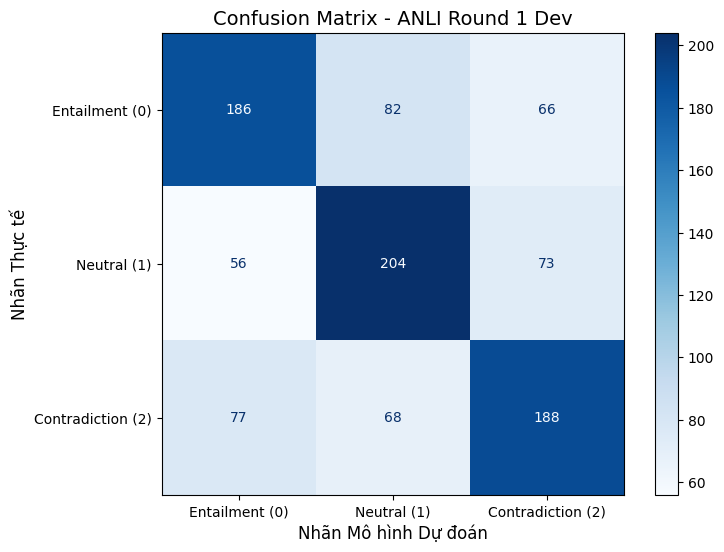

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Chạy dự đoán trên toàn bộ tập Dev R1
print("Đang tiến hành dự đoán trên tập Dev...")
predictions_output = trainer.predict(tokenized_eval)

# 2. Lấy nhãn dự đoán và nhãn thực tế
preds = np.argmax(predictions_output.predictions, axis=-1)
true_labels = predictions_output.label_ids

# 3. Tính toán Confusion Matrix
cm = confusion_matrix(true_labels, preds)

# 4. Vẽ biểu đồ
# ANLI/MNLI thứ tự nhãn chuẩn: 0 = Entailment, 1 = Neutral, 2 = Contradiction
display_labels = ["Entailment (0)", "Neutral (1)", "Contradiction (2)"]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)

# Tùy chỉnh kích thước và màu sắc cho dễ nhìn
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')

plt.title("Confusion Matrix - ANLI Round 1 Dev", fontsize=14)
plt.xlabel("Nhãn Mô hình Dự đoán", fontsize=12)
plt.ylabel("Nhãn Thực tế", fontsize=12)
plt.show()